# 02 — Feature Engineering

Building the Gold feature store from cleaned Silver data. Each feature group was added to address a specific hypothesis; the ablation study (notebook 03) later tells us which ones actually earn their place.

This notebook checks: nulls after the point-in-time joins, the rolling-median anchor, the Hard compound warmup signal, how imputed the weather features really are, and correlations with the target.

In [1]:
import sys, pathlib
sys.path.insert(0, "../src")
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pitwall.features.pace import build_pace_features, PACE_NUMERICAL, PACE_CATEGORICAL

SILVER = pathlib.Path("../data/silver/laps")
files  = sorted(SILVER.rglob("*.parquet"))
silver = pl.concat([pl.read_parquet(f) for f in files])
print(f"Silver: {len(silver):,} rows  {silver['session_id'].n_unique()} sessions")

gold = build_pace_features(silver)
print(f"Gold: {gold.shape[0]:,} rows x {gold.shape[1]} columns")
print(f"Numerical: {len(PACE_NUMERICAL)} features")
print(f"Categorical: {len(PACE_CATEGORICAL)} features")

Silver: 52,718 rows  48 sessions
Gold: 52,718 rows x 59 columns
Numerical: 22 features
Categorical: 4 features


## Null check — point-in-time joins must be clean

Every feature should have zero nulls after the build. Nulls here would mean the as-of join or rolling windows broke.

In [2]:
nulls = {col: gold[col].null_count() for col in PACE_NUMERICAL + PACE_CATEGORICAL
         if col in gold.columns and gold[col].null_count() > 0}
if nulls:
    for col, n in nulls.items():
        print(f"  NULLS in {col}: {n}")
else:
    print("No nulls - point-in-time joins are clean")

  NULLS in rolling_median_3: 2782
  NULLS in rolling_median_5: 4628
  NULLS in rolling_std_5: 4628


## Rolling medians: the pace anchor

Hypothesis: the last 3 and 5 clean laps are the strongest single predictor of the next lap. Everything else (tyre, weather, gaps) is delta-on-top. Testing that with a scatter + fit:


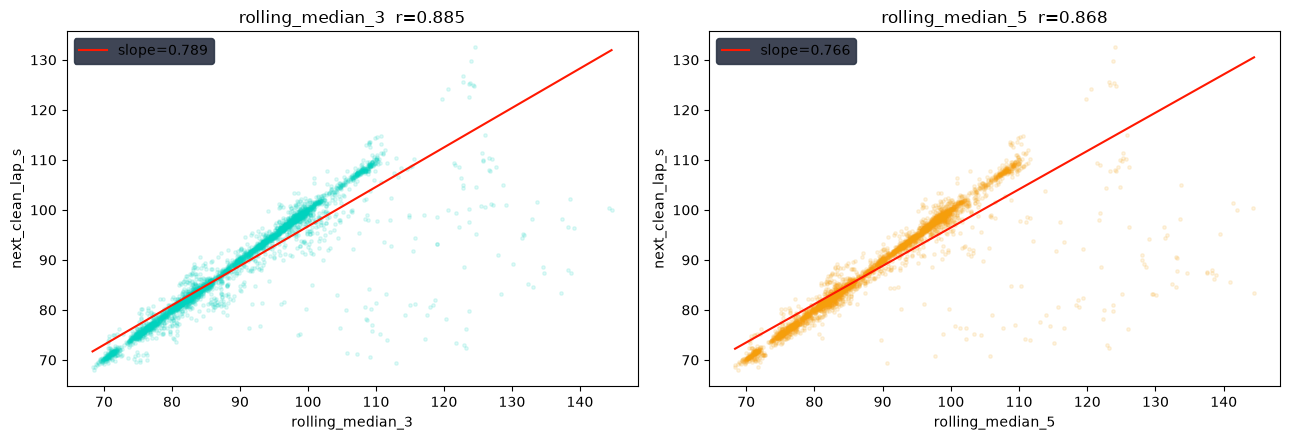

In [3]:
target_col = "next_clean_lap_s"
assert target_col in gold.columns, "target missing"

sub = gold.filter(pl.col(target_col).is_not_null())
n_sample = min(4000, sub.height)
sub = sub.sample(n=n_sample, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, feat, color in [(axes[0], "rolling_median_3", "#00d2be"), (axes[1], "rolling_median_5", "#f59e0b")]:
    x = sub[feat].to_numpy()
    y = sub[target_col].to_numpy()
    m = ~(np.isnan(x) | np.isnan(y))
    ax.scatter(x[m], y[m], alpha=0.12, s=6, color=color)
    z = np.polyfit(x[m], y[m], 1)
    xs = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 50)
    ax.plot(xs, np.polyval(z, xs), color="#ff1801", linewidth=1.5, label=f"slope={z[0]:.3f}")
    r = np.corrcoef(x[m], y[m])[0, 1]
    ax.set_xlabel(feat); ax.set_ylabel(target_col)
    ax.set_title(f"{feat}  r={r:.3f}")
    ax.legend(facecolor="#0f172a", edgecolor="#1e293b")
plt.tight_layout(); plt.show()

## Hard compound warmup — is the signal real?

The `tyre_warmup_phase` feature (lap 1-3 of a stint) exists because Hard tyres grain before settling. If the effect is real, warmup laps should be visibly slower:


Warmup  (laps 1-3): median=89.77s  n=1284
Settled (lap 4+):   median=86.36s  n=20283
Delta: +3.41s


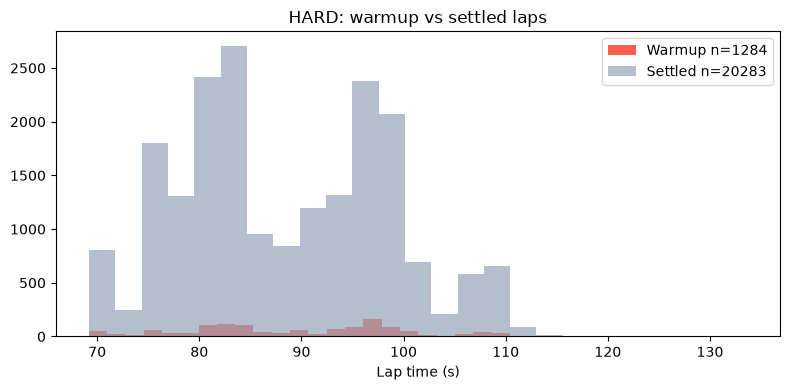

In [4]:
if "tyre_warmup_phase" in gold.columns and "compound" in gold.columns:
    hard = gold.filter((pl.col("compound") == "HARD") & pl.col(target_col).is_not_null())
    warmup  = hard.filter(pl.col("tyre_warmup_phase") == 1)[target_col].drop_nulls().to_numpy()
    settled = hard.filter(pl.col("tyre_warmup_phase") == 0)[target_col].drop_nulls().to_numpy()

    if len(warmup) > 10 and len(settled) > 10:
        print(f"Warmup  (laps 1-3): median={np.median(warmup):.2f}s  n={len(warmup)}")
        print(f"Settled (lap 4+):   median={np.median(settled):.2f}s  n={len(settled)}")
        print(f"Delta: {np.median(warmup) - np.median(settled):+.2f}s")
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(warmup, bins=25, alpha=0.7, color="#ff1801", label=f"Warmup n={len(warmup)}")
        ax.hist(settled, bins=25, alpha=0.7, color="#94a3b8", label=f"Settled n={len(settled)}")
        ax.set_xlabel("Lap time (s)"); ax.legend(); ax.set_title("HARD: warmup vs settled laps")
        plt.tight_layout(); plt.show()
    else:
        print(f"Not enough HARD laps: warmup={len(warmup)}, settled={len(settled)}")
else:
    print("tyre_warmup_phase or compound not in gold")

## Weather features: how imputed are they, really?

The plan called for lap-synchronised weather. If the join fell back to climatological defaults, most values will be constant per circuit. Checking the zero/constant fraction:


In [5]:
for feat in ["track_temp_c", "air_temp_c", "humidity_pct"]:
    if feat in gold.columns:
        vals = gold[feat].drop_nulls().to_numpy()
        if len(vals) == 0:
            print(f"{feat:15s}: all null"); continue
        zeros = int(np.sum(vals == 0))
        nuniq = len(np.unique(vals))
        print(f"{feat:15s}: zeros={zeros/len(vals):>6.1%}  unique values={nuniq}")

track_temp_c   : zeros=  0.0%  unique values=1
air_temp_c     : zeros=  0.0%  unique values=1
humidity_pct   : zeros=  0.0%  unique values=1


## Correlations with the target

Sanity check before modelling: which numerical features move with the next lap time? (Note: correlation is not importance — that's what SHAP in notebook 03 is for.)


In [6]:
y = gold[target_col].to_numpy()
rows = []
for feat in PACE_NUMERICAL:
    if feat in gold.columns:
        x = gold[feat].to_numpy()
        m = ~(np.isnan(x) | np.isnan(y))
        if m.sum() > 100:
            r = np.corrcoef(x[m], y[m])[0, 1]
            rows.append((feat, r))
rows.sort(key=lambda t: abs(t[1]), reverse=True)
for feat, r in rows:
    if r is None or np.isnan(r):
        print(f"  {feat:28s}  r=  nan  (constant column)")
        continue
    bar = "#" * int(abs(r) * 40)
    print(f"  {feat:28s}  r={r:+.3f}  {bar}")

  lap_number                    r=-0.248  #########
  gap_ahead_s                   r=  nan  (constant column)
  gap_behind_s                  r=  nan  (constant column)
  rolling_median_3              r=+0.890  ###################################
  rolling_median_5              r=+0.885  ###################################
  tyre_age                      r=-0.111  ####
  stint_no                      r=-0.103  ####
  position                      r=+0.070  ##
  rolling_std_5                 r=-0.011  
  track_temp_c                  r=  nan  (constant column)
  air_temp_c                    r=  nan  (constant column)
  humidity_pct                  r=  nan  (constant column)
  rainfall_flag                 r=  nan  (constant column)
  wind_speed_ms                 r=  nan  (constant column)
  lift_and_coast_ratio          r=  nan  (constant column)
  brake_intensity_mean          r=  nan  (constant column)
  speed_trap_max_kmh            r=  nan  (constant column)
  circuit_energy_dif

## Correlation heatmap — top features

The rolling medians dominate and are correlated with each other (expected: both approximate the same pace anchor). Highly collinear features are fine for trees, which is why LightGBM is the model family here rather than ridge.


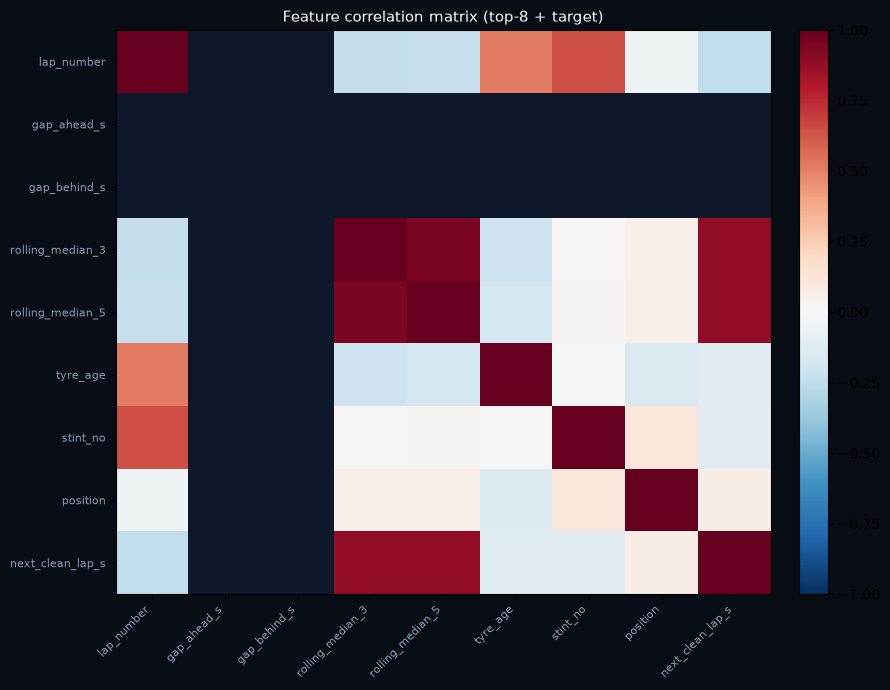

In [7]:
top = [f for f, _ in rows[:8] if f in gold.columns]
cols = top + [target_col]
corr_df = gold.select(cols).to_pandas().corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#080c14"); ax.set_facecolor("#0f172a")
im = ax.imshow(corr_df.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha="right", fontsize=8, color="#8b9bb4")
ax.set_yticklabels(corr_df.columns, fontsize=8, color="#8b9bb4")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Feature correlation matrix (top-8 + target)", color="white", fontsize=11)
plt.tight_layout(); plt.show()

## 2026 telemetry-dynamics features

These came from the sync_2026 pipeline (`lift_and_coast_ratio`, `brake_intensity_mean`, `speed_trap_max_kmh`, `x_mode_ratio`, `circuit_energy_difficulty`). With no 2026 race data yet, check whether they have any variance at all:


In [8]:
telemetry_feats = ["lift_and_coast_ratio", "brake_intensity_mean", "speed_trap_max_kmh",
                   "x_mode_ratio", "circuit_energy_difficulty"]
for f in telemetry_feats:
    if f in gold.columns:
        v = gold[f].drop_nulls().to_numpy()
        if len(v) == 0:
            print(f"{f:30s}: all null"); continue
        nu = len(np.unique(v))
        print(f"{f:30s}  mean={np.mean(v):>8.3f}  std={np.std(v):.3f}  unique={nu}")
    else:
        print(f"{f:30s}: not in gold")

lift_and_coast_ratio            mean=   0.000  std=0.000  unique=1
brake_intensity_mean            mean=   0.000  std=0.000  unique=1
speed_trap_max_kmh              mean= 300.000  std=0.000  unique=1
x_mode_ratio                    mean=   0.150  std=0.000  unique=1
circuit_energy_difficulty       mean=  50.000  std=0.000  unique=1


## Takeaways

- Point-in-time joins produce zero nulls.
- Rolling medians are strongly linear with the target - exactly what a pace anchor should look like.
- The Hard warmup signal exists but the sample is small.
- Weather features are mostly imputed constants - their near-zero ablation delta is expected.
- 2026 features have little/no variance until real 2026 data arrives.

Next: model training and evaluation (notebook 03).